In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torch import nn
from torch import optim

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")#пробую перевести на гп

1. Скачайте датасет mnist

In [ ]:
train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_loader = DataLoader(
    train_data,
    batch_size=100,
    shuffle=True
)
test_loader = DataLoader(
    test_data,
    batch_size=100,
    shuffle=False
)
'''в этом наутбуке буду использовать тестовую выборку как валидацию потому что нет пуктов со сравненим с тестовой.
плюс удобно что они уже не пересекаются.
ниже почитано сколько элементов каждого класса. видно что удобно что выборки стратифицированы'''

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:01<00:00, 5.34MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.55MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 6.04MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



'в этом наутбуке буду использовать тестовую выборку как валидацию потому что нет пуктов со сравненим с тестовой.\nплюс удобно что они уже не пересекаются.\nниже почитано сколько элементов каждого класса. видно что удобно что выборки стратифицированы'

In [ ]:
for X, y in train_loader:
    print(X.shape, y.shape)
    break

torch.Size([100, 1, 28, 28]) torch.Size([100])


2. Напишите модель, подобную модели с первой части семинара.

In [ ]:
model_seminar = nn.Sequential(
    nn.Linear(in_features=784, out_features=512),
    nn.ReLU(),
    nn.Linear(in_features=512, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10)
)
model_seminar.to(device)
model_seminar

Sequential(
  (0): Linear(in_features=784, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=10, bias=True)
)

3. Выведите summary модели.

In [ ]:
from torchsummary import summary

summary(model_seminar, input_size=(1, 784))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1               [-1, 1, 512]         401,920
              ReLU-2               [-1, 1, 512]               0
            Linear-3               [-1, 1, 128]          65,664
              ReLU-4               [-1, 1, 128]               0
            Linear-5                [-1, 1, 10]           1,290
Total params: 468,874
Trainable params: 468,874
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 1.79
Estimated Total Size (MB): 1.80
----------------------------------------------------------------


In [ ]:
# посмотреть что выдвет с ненастроенными весами
with torch.no_grad():
    x, y = train_data[0]
    x=x.view(1,-1)
    x = x.to(device)
    y_pred = model_seminar(x).argmax(dim=1).item()#тк задача класификации
    print(f'y_true = {y}')
    print(f'y_pred = {y_pred}')

y_true = 5
y_pred = 4


In [ ]:
import pandas as pd
number = [y for x, y in train_data]
df = pd.DataFrame(number, columns=['number'])
df['number'].value_counts()#просто глянуть баланс классов ради интереса

,count
number,
1,6742
7,6265
3,6131
2,5958
9,5949
0,5923
6,5918
8,5851
4,5842


In [ ]:
import pandas as pd
number = [y for x, y in test_data]
df = pd.DataFrame(number, columns=['number'])
df['number'].value_counts()

,count
number,
1,1135
2,1032
7,1028
3,1010
9,1009
4,982
0,980
8,974
6,958


4. Обучите модель, добавив коллбек построения графиков обучения, напишите выводы: сошлась ли модель по итогам обучения.

In [ ]:
loss_function = nn.CrossEntropyLoss()#задача класификации поэтому такая функуия потерь

In [ ]:
optimizer = optim.SGD(model_seminar.parameters(), lr=1e-1)#на лекции использовали обычный градиентный спуск но я знаю что еще есть адам

In [ ]:
def run(model, dataloader, loss_function, optimizer=None):
    # set the model to evaluation or training mode
    if optimizer is None:
        model.eval()
    else:
        model.train()

    total_loss = 0
    all_preds = []#потом понадобятся в расчете метрик
    all_truth = []

    for X, y in dataloader:
        # compute prediction
        X = X.view(X.size(0), -1)

        X = X.to(device)#перевожу на гп
        y = y.to(device)

        pred = model(X)
        # compute loss
        loss = loss_function(pred, y)
        # save loss
        total_loss += loss.item()

        all_preds.extend(pred.argmax(dim=1).cpu().numpy())#я до этого перводила все на гп поэтому тут надо на процессор для вывода перевести обратно
        all_truth.extend(y.cpu().numpy())


        if optimizer != None:
            # compute gradients
            loss.backward()
            # do optimizer step
            optimizer.step()
            # clear gradients
            optimizer.zero_grad()

    return total_loss / len(dataloader), all_preds, all_truth

In [ ]:
from IPython.display import clear_output

def show_losses(train_loss_hist, test_loss_hist):
    clear_output()

    plt.figure(figsize=(12,4))

    plt.subplot(1, 2, 1)
    plt.title('Train Loss')
    plt.plot(np.arange(len(train_loss_hist)), train_loss_hist)
    plt.yscale('log')
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.title('Test Loss')
    plt.plot(np.arange(len(test_loss_hist)), test_loss_hist)
    plt.yscale('log')
    plt.grid()

    plt.show()

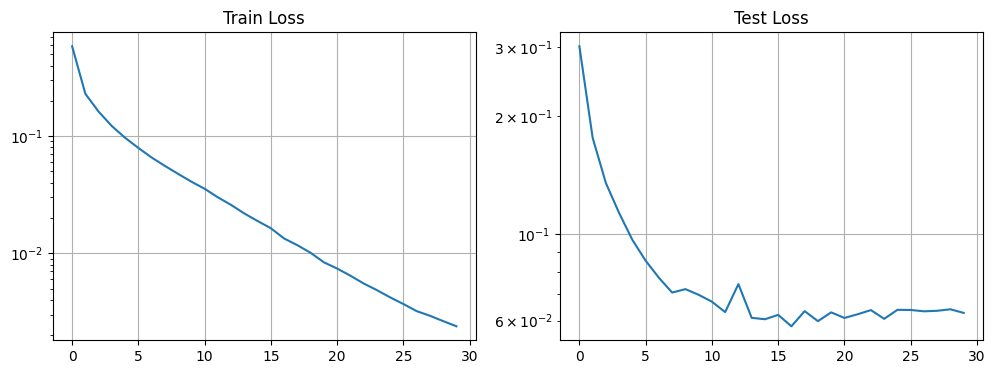

In [ ]:
NUM_EPOCHS = 30

train_loss_hist = []
test_loss_hist = []

for i in range(NUM_EPOCHS):
    train_loss, _, _ = run(model_seminar, train_loader, loss_function, optimizer)
    train_loss_hist.append(train_loss)
    test_loss, test_preds, test_truth = run(model_seminar, test_loader, loss_function)
    test_loss_hist.append(test_loss)
    if i % 5 == 4:  # строим график каждые 5 эпох
        show_losses(train_loss_hist, test_loss_hist)

#по итогу слишком много эпох модель с такой архитектурой переучилась. там ошибка на валидации начинает увеличиваться я проверяла на больщем кол-ве эпох

5. Сравните несколько архитектур, в том числе с различным количеством слоёв и подберите оптимальную. Обязательно используйте dropout и batchnorm и поясните свои выводы. Также можно попробовать различные активации в скрытых слоях.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [ ]:
models = {
    "model_2_layer_tag": nn.Sequential(
        nn.Linear(28 * 28, 512),
        nn.BatchNorm1d(512),
        nn.Sigmoid(),
        nn.Linear(512, 10)
    ),
    "model_3_layer_batchnorm": nn.Sequential(
        nn.Linear(28 * 28, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Linear(512, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Linear(128, 10)

    ),
        "model_3_layer_dropout_batchnorm": nn.Sequential(
        nn.Linear(28 * 28, 512),
        nn.BatchNorm1d(512),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.3),
        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.2),
        nn.Linear(256, 10)

    ),
    "model_4_layer_dropout_batchnorm": nn.Sequential(
        nn.Linear(28 * 28, 1024),
        nn.BatchNorm1d(1024),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(1024, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, 10)
    )
}
'''
в первой модели попробовада другую функцию активации
во второй подключила бачнорм
в третей плюсом добавила дропаут и прочитала чт оесть ликирелу что это спасает от мертвых нейронов. думаю она будет ссамая выйгрышная
четвертую решила накрутить немного увидела что есть архмтектуры с увеличением а потом понижением выходов

'''

'\nв первой модели попробовада другую функцию активации\nво второй подключила дропаут и бечнорм ставлю на эту модель ставки\nтретью решила накрутить немного увидела что есть архмтектуры с увеличением а потом понижением выходов\n\n'

In [ ]:
def plot_all_losses(results):
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.title("Train Loss")
    for model_name, history in results.items():
        plt.plot(history["train_loss"], label=model_name)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.title("Test Loss")
    for model_name, history in results.items():
        plt.plot(history["test_loss"], label=model_name)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()



In [ ]:
NUM_EPOCHS=100

results = {}

for model_name, model in models.items():

    model.to(device)

    train_loss_hist = []
    test_loss_hist = []
    accuracy_hist = []
    precision_hist = []
    recall_hist = []
    f1_hist = []

    optimizer = optim.SGD(model.parameters(), lr=0.01)

    for i in range(NUM_EPOCHS):
        train_loss,_ ,_ = run(model, train_loader, loss_function, optimizer)
        train_loss_hist.append(train_loss)
        test_loss, test_preds, test_truth = run(model, test_loader, loss_function)
        test_loss_hist.append(test_loss)

        acc = accuracy_score(test_truth, test_preds)
        precision = precision_score(test_truth, test_preds, average='weighted')#тк многоклассовая класификация то беру средневзвешенную
        recall = recall_score(test_truth, test_preds, average='weighted')
        f1 = f1_score(test_truth, test_preds, average='weighted')

        accuracy_hist.append(acc)
        precision_hist.append(precision)
        recall_hist.append(recall)
        f1_hist.append(f1)

    results[model_name] = {
        "train_loss": train_loss_hist,
        "test_loss": test_loss_hist,
        "accuracy": accuracy_hist,
        "precision": precision_hist,
        "recall": recall_hist,
        "f1_score": f1_hist
    }
#сразу все метрики и лоссы считаю чтобы не запускать еще ячейку с вычислениями

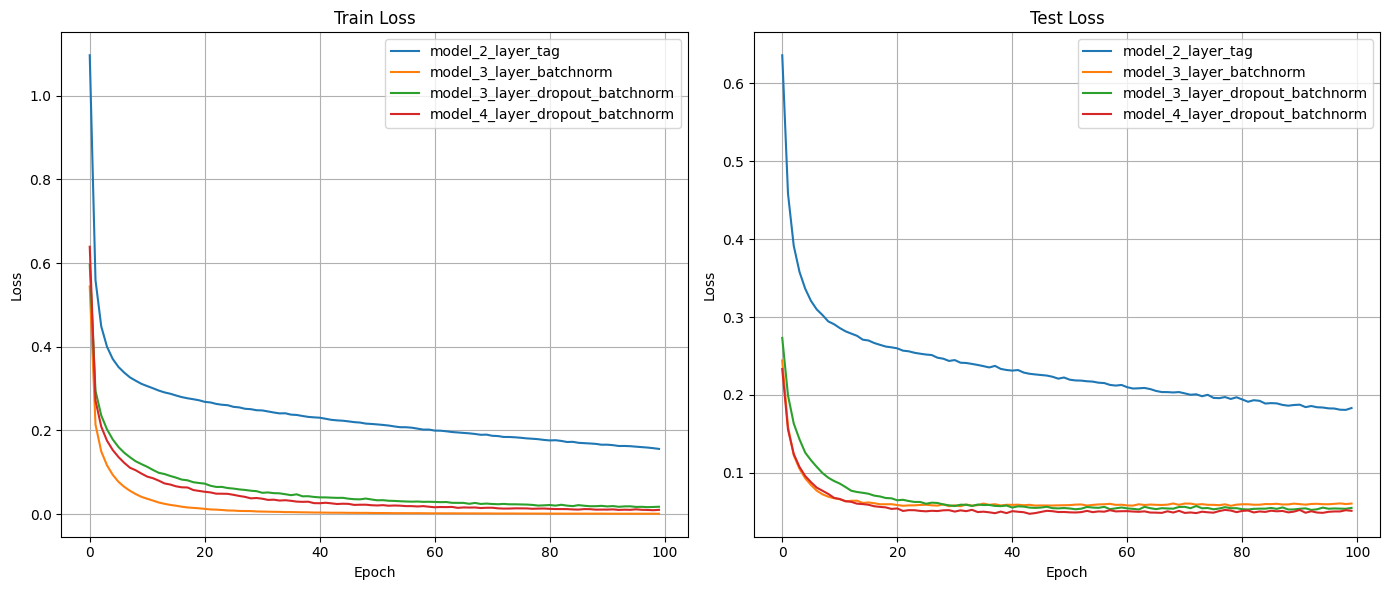

In [ ]:
plot_all_losses(results)


6. В конце напишите выводы и отчет о рассмотренных моделях. Отчёт должен быть в виде таблички, в которой описан номер эксперимента, минимальная ошибка на валидации, 4 классификационные метрики на тесте: аccuracy, precision, recall и f1-score, к отчету должно прилагаться описание. Выводы ожидаются в свободной форме и должны содержать информацию о том, почему, по вашему мнению, именно эта архитектура из рассмотренных получила наилучший скор на тесте.

In [ ]:
report = []

for i, (model_name, result) in enumerate(results.items()):#иду по словарю
    min_test_loss = min(result["test_loss"])#писала выше что в этом задании беру тест как валидацию
    best_epoch = result["test_loss"].index(min_test_loss)

    accuracy = result["accuracy"][best_epoch]
    precision = result["precision"][best_epoch]
    recall = result["recall"][best_epoch]
    f1 = result["f1_score"][best_epoch]

    report.append({
        "№ эпохи": best_epoch,
        "Модель": model_name,
        "Мин ошибка на валидации": min_test_loss,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

report_df = pd.DataFrame(report)
report_df


,№ эпохи,Модель,Мин ошибка на валидации,Accuracy,Precision,Recall,F1-Score
0,98,model_2_layer_tag,0.180691,0.9485,0.948489,0.9485,0.948413
1,31,model_3_layer_batchnorm,0.056895,0.9828,0.982813,0.9828,0.982796
2,92,model_3_layer_dropout_batchnorm,0.052216,0.9841,0.984112,0.9841,0.984099
3,43,model_4_layer_dropout_batchnorm,0.047221,0.9853,0.985312,0.9853,0.985300


По модели с двумя слоями видно что очень медлено уменьшаеся лос. за данное количество эпох недообучилась. видимо произошло затухание градиента. вероятно тут как раз шаг нужен побольше

вторая модель быстро сошлась.там немного не видно из-за масштаба графика но походу там есть переобучение тк на трейне точно в ноль ошибка уходит, а вот на тесте чуть побольше.

третья архитектура неплохая но долго обучалась но метрики хорошие(но конечно не суперский результат по сравнеию со второй моделью та все таки в три раза быстрее сошлась)


4 модель выдает самый лучший результат. сошлась быстрее чем 3, верояно из-за другой функции активации, все таки не зря релу так распростронена.


на удивление самая сложная модель оказалась самая оптимальная, она выдает хороший результат и быстро сходится.